<a href="https://colab.research.google.com/github/Ishany0/Liver-disease-detection-using-ultrasound-imaging/blob/main/EfficientNetB0_and_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [115]:
import kagglehub
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [116]:
path = kagglehub.dataset_download("mahendarbyra/behsof-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'behsof-dataset' dataset.
Path to dataset files: /kaggle/input/behsof-dataset


In [117]:
import os

for root, dirs, files in os.walk(path):
    level = root.replace(path, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = "  " * (level + 1)
    for f in files[:5]:
        print(f"{subindent}{f}")
    if len(files) > 5:
        print(f"{subindent}... ({len(files)} files total)")

behsof-dataset/
  BEHSOF/
    NAFLD/
      nafld_957.jpg
      nafld_222.jpg
      nafld_1467.jpg
      nafld_1120.jpg
      nafld_678.jpg
      ... (1517 files total)
    Non-NAFLD/
      non_nafld_85.jpg
      non_nafld_77.jpg
      non_nafld_0.jpg
      non_nafld_2.jpg
      non_nafld_67.jpg
      ... (152 files total)


In [118]:
from pathlib import Path
import shutil
from sklearn.model_selection import train_test_split

src = Path(path) / "BEHSOF"
out = Path("BEHSOF_split")

for cls in ['NAFLD','Non-NAFLD']:
  files = list((src/cls).glob('*.jpg'))
  train , temp = train_test_split(files , test_size = 0.3, random_state = 42)
  dev , test = train_test_split(temp, test_size = 0.5 , random_state = 42)
  for split , flist in zip(['train' , 'dev' , 'test'] , [train , dev , test]):
    d = out / split / cls
    d.mkdir(parents = True , exist_ok = True)
    for f in flist:
      shutil.copy(f,d / f.name)

print("Done: ", out.resolve())

for split in ["train", "dev", "test"]:
    for cls in ["NAFLD", "Non-NAFLD"]:
        d = f"/content/BEHSOF_split/{split}/{cls}"
        print(split, cls, len(os.listdir(d)))

Done:  /content/BEHSOF_split
train NAFLD 1061
train Non-NAFLD 1061
dev NAFLD 228
dev Non-NAFLD 23
test NAFLD 228
test Non-NAFLD 23


In [119]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=8,
    horizontal_flip=True,
    vertical_flip=False,
    brightness_range=[0.9, 1.1],
    zoom_range=0.05,
)

dev_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen = dev_datagen

In [120]:
IMG_SIZE = 224

train_dataset = train_datagen.flow_from_directory(
    "/content/BEHSOF_split/train",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=32,
    class_mode='binary',
    shuffle=True,
)

dev_dataset = dev_datagen.flow_from_directory(
    "/content/BEHSOF_split/dev",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=32,
    class_mode='binary',
    shuffle=False,
)

test_dataset = test_datagen.flow_from_directory(
    "/content/BEHSOF_split/test",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=32,
    class_mode='binary',
    shuffle=False,
)

Found 2122 images belonging to 2 classes.
Found 251 images belonging to 2 classes.
Found 251 images belonging to 2 classes.


In [121]:
def binary_focal_loss(gamma=2.0, alpha=0.75):
    def loss_fn(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1.0 - epsilon)

        pt = tf.where(tf.equal(y_true, 1), y_pred, 1 - y_pred)
        alpha_t = tf.where(tf.equal(y_true, 1), alpha, 1 - alpha)

        loss = -alpha_t * tf.pow(1 - pt, gamma) * tf.math.log(pt)
        return tf.reduce_mean(loss)
    return loss_fn

In [122]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout , GlobalAveragePooling2D , Conv2D , MaxPooling2D
from tensorflow.keras.regularizers import l2

eff_base = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
eff_base.trainable = False

model = Sequential([
    eff_base,
    Conv2D(64 , (2,2) , activation = 'relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    MaxPooling2D((2,2), padding='same'),
    Conv2D(64 , (2,2) , activation = 'relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    MaxPooling2D((2,2), padding='same'),
    GlobalAveragePooling2D(),
    Dense(128, activation='relu', kernel_regularizer=l2(1e-4)),
    Dropout(0.5),
    Dense(64, activation='relu',kernel_regularizer=l2(1e-4)),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])
model.build((None, IMG_SIZE, IMG_SIZE, 3))
print(model.summary())

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 7, 7, 64)       │       327,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_31          │ (None, 7, 7, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_31 (MaxPooling2D) │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 4, 4, 64)       │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_32          │ (None, 4, 4, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_32 (MaxPooling2D) │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_13     │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,410,916 (16.83 MB)

 Trainable params: 361,089 (1.38 MB)

 Non-trainable params: 4,049,827 (15.45 MB)

None


In [123]:
class Early_Stopping_Callback(tf.keras.callbacks.Callback):
  def on_epoch_end(self,epoch,logs=None):
    if logs['loss'] <0.01:
      print('\nLoss is low so cancelling training')
      self.model.stop_training = True


In [124]:
early_stop_phase1 = tf.keras.callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=8, restore_best_weights=True)
reduce_lr_phase1 = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_auc', mode='max', patience=3, factor=0.5, min_lr=1e-6)

In [125]:
from tensorflow.keras.metrics import Precision, Recall, AUC

model.compile(
    optimizer='adam',
    loss=binary_focal_loss(gamma=2.0, alpha=0.75),  # alpha=0.75 favors the minority (Non-NAFLD) class
    metrics=[
        'accuracy',
        Precision(name='precision'),
        Recall(name='recall'),
        AUC(name='auc'),
    ]
)

EPOCHS_PHASE1 = 20

history = model.fit(train_dataset, epochs=EPOCHS, validation_data=dev_dataset , class_weight=class_weight_dict , callbacks=[Early_Stopping_Callback(), early_stop_phase1, reduce_lr_phase1])

Epoch 1/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 122s 2s/step - accuracy: 0.7502 - auc: 0.8708 - loss: 0.0720 - precision: 0.6934 - recall: 0.8973 - val_accuracy: 0.9124 - val_auc: 0.8763 - val_loss: 0.0547 - val_precision: 0.5385 - val_recall: 0.3043 - learning_rate: 0.0010
Epoch 2/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 108s 2s/step - accuracy: 0.9147 - auc: 0.9780 - loss: 0.0386 - precision: 0.8780 - recall: 0.9632 - val_accuracy: 0.9084 - val_auc: 0.9221 - val_loss: 0.0525 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 106s 2s/step - accuracy: 0.9387 - auc: 0.9866 - loss: 0.0319 - precision: 0.9087 - recall: 0.9755 - val_accuracy: 0.9124 - val_auc: 0.9090 - val_loss: 0.0561 - val_precision: 0.5263 - val_recall: 0.4348 - learning_rate: 0.0010
Epoch 4/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 106s 2s/step - accuracy: 0.9467 - auc: 0.9913 - loss: 0.0277 - precision: 0.9217 - recall: 0.9764 - val_accuracy: 0.9163 - val_auc: 0.9367 - val_loss: 0.0489 -

In [126]:
eff_base.trainable = True
for layer in eff_base.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5,clipnorm=1.0),
    loss=binary_focal_loss(gamma=2.0, alpha=0.75),
    metrics=['accuracy', Precision(name='precision'), Recall(name='recall'), AUC(name='auc')]
)

early_stop_phase2 = tf.keras.callbacks.EarlyStopping(
    monitor='val_auc', mode='max', patience=6, restore_best_weights=True
)
reduce_lr_phase2 = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', mode='min', patience=5, factor=0.5, min_lr=1e-7
)
EPOCHS_PHASE2 = 15
history_finetune= model.fit(train_dataset, epochs=EPOCHS_PHASE2, validation_data=dev_dataset , class_weight=class_weight_dict , callbacks=[early_stop_phase2, reduce_lr_phase2])

Epoch 1/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - accuracy: 0.9500 - auc: 0.9913 - loss: 0.0286 - precision: 0.9237 - recall: 0.9811 - val_accuracy: 0.9442 - val_auc: 0.9700 - val_loss: 0.0543 - val_precision: 1.0000 - val_recall: 0.3913 - learning_rate: 1.0000e-05
Epoch 2/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 124s 2s/step - accuracy: 0.9647 - auc: 0.9961 - loss: 0.0186 - precision: 0.9418 - recall: 0.9906 - val_accuracy: 0.9363 - val_auc: 0.9621 - val_loss: 0.0588 - val_precision: 0.8889 - val_recall: 0.3478 - learning_rate: 1.0000e-05
Epoch 3/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 124s 2s/step - accuracy: 0.9656 - auc: 0.9954 - loss: 0.0203 - precision: 0.9499 - recall: 0.9830 - val_accuracy: 0.9283 - val_auc: 0.9580 - val_loss: 0.0652 - val_precision: 0.7778 - val_recall: 0.3043 - learning_rate: 1.0000e-05
Epoch 4/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 123s 2s/step - accuracy: 0.9736 - auc: 0.9980 - loss: 0.0165 - precision: 0.9589 - recall: 0.9896 - val_accuracy: 0.9442 - val_auc: 0.9579 - val_loss: 0.05

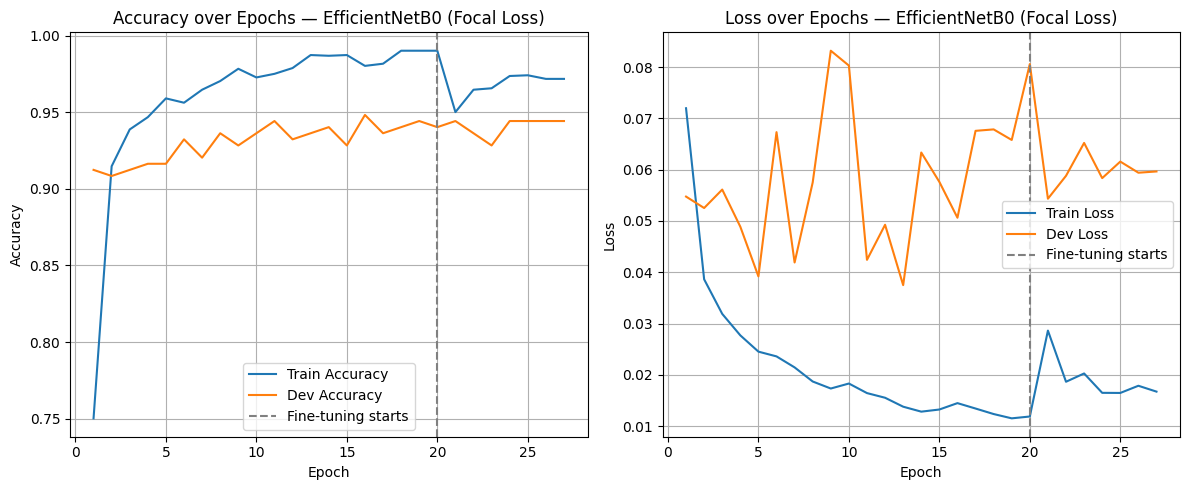

In [127]:
import matplotlib.pyplot as plt


acc = history.history['accuracy'] + history_finetune.history['accuracy']
val_acc = history.history['val_accuracy'] + history_finetune.history['val_accuracy']
loss = history.history['loss'] + history_finetune.history['loss']
val_loss = history.history['val_loss'] + history_finetune.history['val_loss']
epochs_range = range(1, len(acc) + 1)
finetune_start = len(history.history['accuracy'])

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Train Accuracy')
plt.plot(epochs_range, val_acc, label='Dev Accuracy')
plt.axvline(finetune_start, color='gray', linestyle='--', label='Fine-tuning starts')
plt.title('Accuracy over Epochs — EfficientNetB0 (Focal Loss)'); plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Train Loss')
plt.plot(epochs_range, val_loss, label='Dev Loss')
plt.axvline(finetune_start, color='gray', linestyle='--', label='Fine-tuning starts')
plt.title('Loss over Epochs — EfficientNetB0 (Focal Loss)'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()



Evaluating on test dataset:
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.9562 - auc: 0.9537 - loss: 0.0508 - precision: 0.9286 - recall: 0.5652
ACCURACY: 0.9561753273010254
LOSS: 0.05083049088716507
8/8 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step
Best threshold (from dev): 0.330 | Best F1 (dev): 0.762
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step

Classification report (test, using dev-tuned threshold):
              precision    recall  f1-score   support

       NAFLD       0.97      0.98      0.98       228
   Non-NAFLD       0.77      0.74      0.76        23

    accuracy                           0.96       251
   macro avg       0.87      0.86      0.87       251
weighted avg       0.96      0.96      0.96       251

AUC score: 0.9633867276887872
Sensitivity (recall, Non-NAFLD): 0.7391304347826086
Specificity (recall, NAFLD): 0.9780701754385965


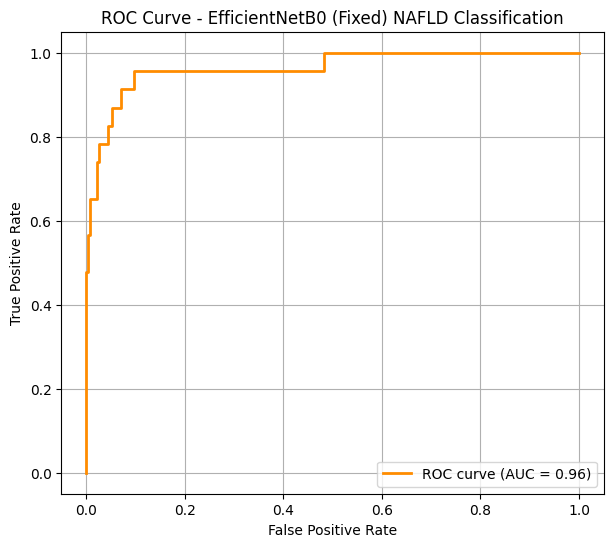

In [128]:
from sklearn.metrics import f1_score, classification_report, confusion_matrix, roc_curve, roc_auc_score

print("Evaluating on test dataset:")
results = model.evaluate(test_dataset)
print("ACCURACY:", results[1])
print("LOSS:", results[0])

dev_dataset.reset()
y_dev_true = dev_dataset.classes
y_dev_prob = model.predict(dev_dataset).ravel()

thresholds = np.linspace(0.01, 0.99, 99)
f1s = [f1_score(y_dev_true, (y_dev_prob >= t).astype(int)) for t in thresholds]
best_threshold = thresholds[np.argmax(f1s)]
print(f"Best threshold (from dev): {best_threshold:.3f} | Best F1 (dev): {max(f1s):.3f}")

test_dataset.reset()
y_test_true = test_dataset.classes
y_test_prob = model.predict(test_dataset).ravel()
y_test_pred = (y_test_prob >= best_threshold).astype(int)

print("\nClassification report (test, using dev-tuned threshold):")
print(classification_report(y_test_true, y_test_pred, target_names=['NAFLD', 'Non-NAFLD']))
print("AUC score:", roc_auc_score(y_test_true, y_test_prob))

cm = confusion_matrix(y_test_true, y_test_pred)
TN, FP, FN, TP = cm.ravel()
print("Sensitivity (recall, Non-NAFLD):", TP / (TP + FN))
print("Specificity (recall, NAFLD):", TN / (TN + FP))

fpr, tpr, _ = roc_curve(y_test_true, y_test_prob)
auc_score = roc_auc_score(y_test_true, y_test_prob)
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.2f})')
plt.legend(loc='lower right')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve - EfficientNetB0 (Fixed) NAFLD Classification')
plt.grid(True); plt.show()
